In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'pd_neuro'
analysis_name = 'pd_dyskinesia'
outcome_name = 'FutureDyskinesia'
build_ensemble_csv(analysis_name, outcome_name)


active_at_bl = pd.read_csv(f'../data/{dataset}/clusters/active_neuro_dyskinesia.csv')
all_patients = pd.read_csv(f'../data/{dataset}/X_neuroart_v4.csv')
# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']

# remove patient in postion 87 from all_patients and active_at_bl because this patiente is never tested
all_patients = all_patients.drop(index=87)

# remove from full training preds the active patients at bl
non_active_idx = all_patients.index[~all_patients.index.isin(active_at_bl['Unnamed: 0'])]


all_patients_non_active = all_patients[all_patients.index.isin(non_active_idx)]

# filter out active patients at bl from the mean training predictions
patients_stats_filtered = patients_stats[patients_stats['idx'].isin(non_active_idx)]

# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats_filtered['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats_filtered['idx'].values)

Successfully aggregated 10500 predictions across 246 unique patients.


Baseline entropy: 0.8718686865491422


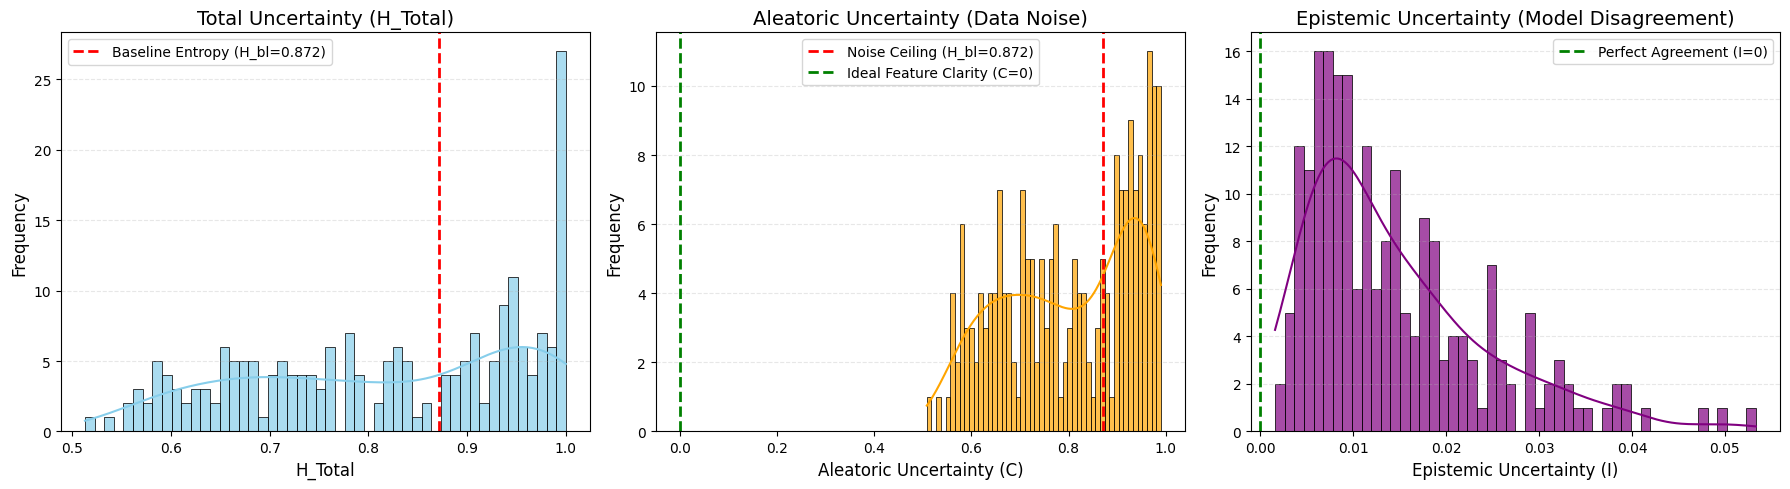

In [2]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_filtered = patients_stats_filtered.copy()

# 2. Add the results to your main stats table
patients_stats_filtered['H_Total'] = uncertainty_results['H_Total']
patients_stats_filtered['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_filtered['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients_non_active['FutureDyskinesia'].sum() / len(all_patients_non_active)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     uncertainty_results, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

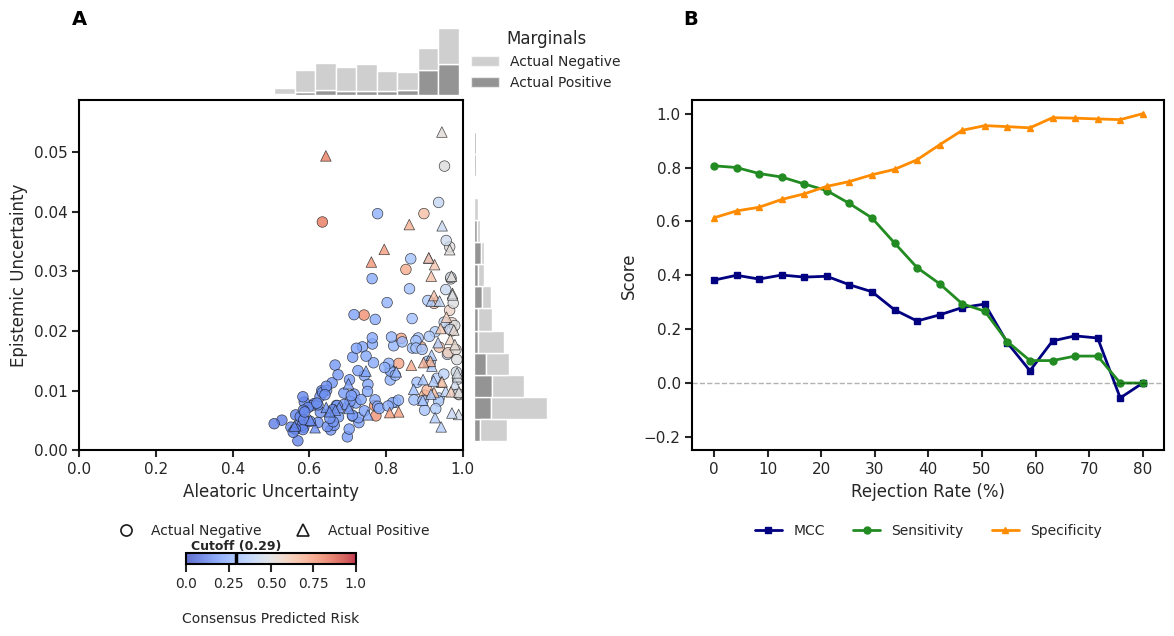

In [3]:
plot_combined_uncertainty_analysis(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])


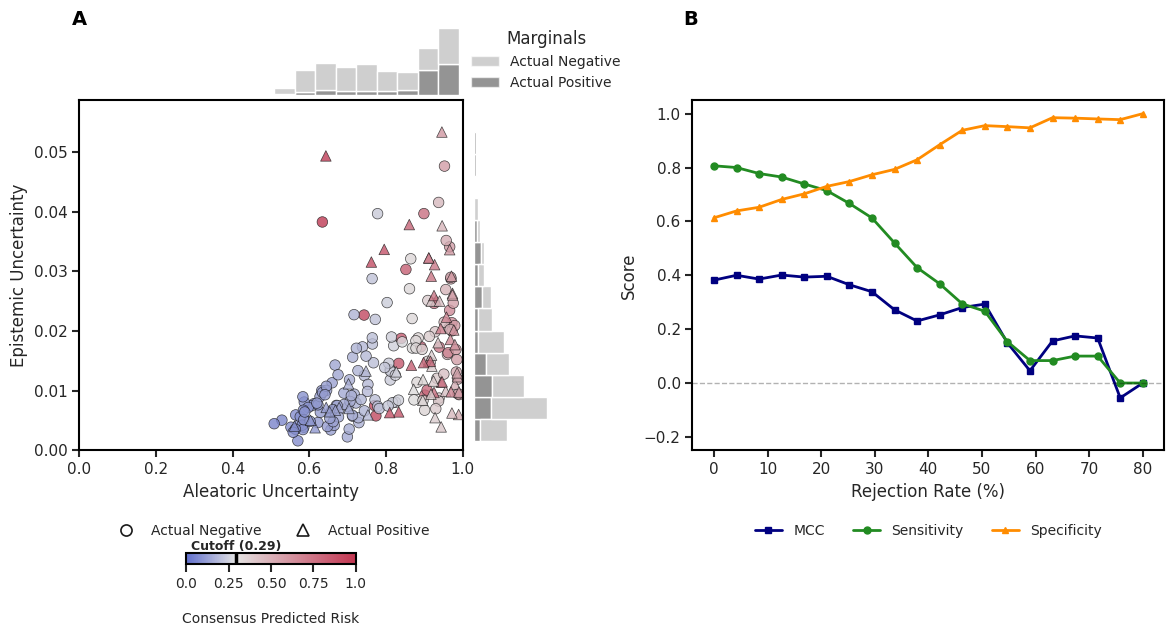

In [ ]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])